# QAOA - Test on MaxCut instance

We test the QAOA on the MaxCut instance from the lab with 5 nodes.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from qiskit_aer import AerSimulator

from Problem.IsingProblem import IsingProblem
from Problem.MaxCutProblem import MaxCutProblem
from Algorithm.Classical_Algorithm.Exhaustive_search import exhaustive_search
from quantum_solver.qaoa_solver.qaoa_mixers import build_qaoa_circuit
from quantum_solver.qaoa_solver.qaoa_optimizer import QAOALocalOptimizer

## Create the MaxCut Ising instance

Graph with 5 nodes, edges: (1,5), (2,5), (3,5), (4,5). Cost function to minimize: s1*s5 + s2*s5 + s3*s5 + s4*s5

In [2]:
# Create the Ising problem corresponding to the maxcut instance
G_ising = nx.Graph()
for i in range(5):
    G_ising.add_node(i, weight=0.0)
# Edges: node 0-3 connected to node 4 (using 0-indexed)
G_ising.add_edge(0, 4, weight=-1.0)
G_ising.add_edge(1, 4, weight=-1.0)
G_ising.add_edge(2, 4, weight=-1.0)
G_ising.add_edge(3, 4, weight=-1.0)
ising = IsingProblem(G_ising)
print(f"Number of qubits : {ising.n}")

# Find optimal
best_sol, best_cost = exhaustive_search(ising, maximize=False)
print(f"Optimal solution : {best_sol}")
print(f"Optimal cost : {best_cost}")

Number of qubits : 5
Optimal solution : {'s_0': -1, 's_1': -1, 's_2': -1, 's_3': -1, 's_4': -1}
Optimal cost : -4.0


## Build and test the QAOA circuit

Circuit : 5 qubits
Parameters : ['gamma_0', 'beta_0']


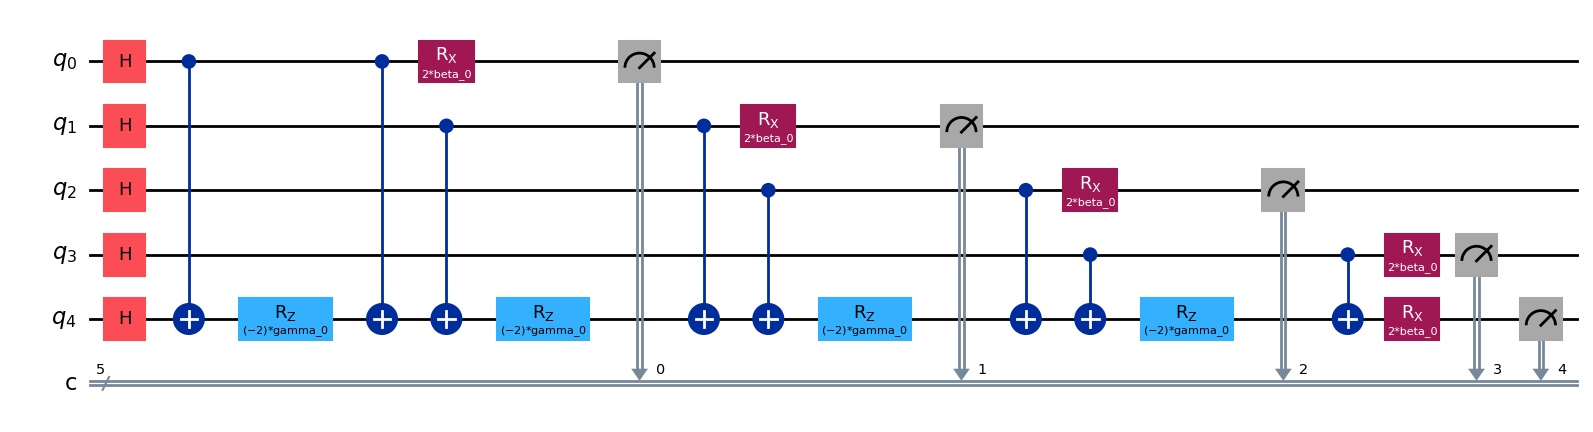

In [3]:
# Build the circuit
qc, params = build_qaoa_circuit(ising, p=1)
print(f"Circuit : {qc.num_qubits} qubits")
print(f"Parameters : {[p.name for p in params]}")
qc.draw('mpl')

In [4]:
# Test with random angles
optimizer = QAOALocalOptimizer(p=1, shots=2048)
exp_val, best_found, angles = optimizer.run_without_optimization(ising, angles=[0.5, 0.5])
print(f"Random angles : {angles}")
print(f"Expectation value : {exp_val:.4f}")
print(f"Best solution : {best_found}")

Random angles : [0.5, 0.5]
Expectation value : 1.7949
Best solution : {'s_0': -1, 's_1': -1, 's_2': -1, 's_3': -1, 's_4': -1}


## Heatmap of expectation values

We iterate over gamma in [0, pi] and beta in [0, pi] for 50 points each.

In [5]:
# Build heatmap
n_points = 50
gammas = np.linspace(0, np.pi, n_points)
betas = np.linspace(0, np.pi, n_points)
heatmap = np.zeros((n_points, n_points))

qc_heat, params_heat = build_qaoa_circuit(ising, p=1)
opt_heat = QAOALocalOptimizer(p=1, shots=512)  # fewer shots for speed

for i, gamma in enumerate(gammas):
    for j, beta in enumerate(betas):
        exp_val = opt_heat.get_expectation_value([gamma, beta], qc_heat, ising)
        heatmap[j, i] = exp_val  # j for beta (y-axis), i for gamma (x-axis)
    if i % 10 == 0:
        print(f"Progress : {i}/{n_points}")

print("Done!")

Progress : 0/50


Progress : 10/50


Progress : 20/50


Progress : 30/50


Progress : 40/50


Done!


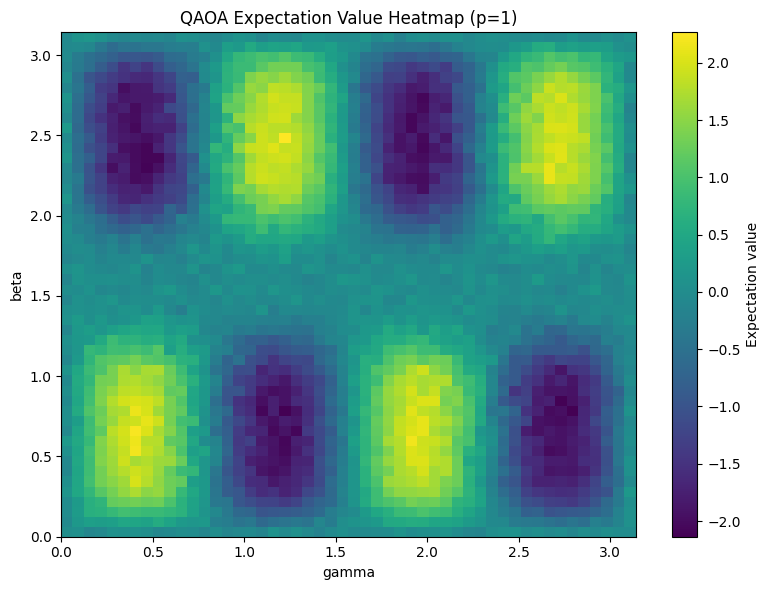

Best gamma from heatmap : 1.2182
Best beta from heatmap : 0.7694
Best expectation value : -2.1367


In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(heatmap, extent=[0, np.pi, 0, np.pi], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Expectation value')
plt.xlabel('gamma')
plt.ylabel('beta')
plt.title('QAOA Expectation Value Heatmap (p=1)')
plt.tight_layout()
plt.show()

# Find the best angles from the heatmap
min_idx = np.unravel_index(np.argmin(heatmap), heatmap.shape)
best_beta_idx, best_gamma_idx = min_idx
print(f"Best gamma from heatmap : {gammas[best_gamma_idx]:.4f}")
print(f"Best beta from heatmap : {betas[best_beta_idx]:.4f}")
print(f"Best expectation value : {heatmap[min_idx]:.4f}")

We can see the characteristic pattern of the QAOA expectation landscape. The dark regions correspond to lower (better) expectation values. The heatmap shows that the QAOA can find good solutions when the angles are tuned correctly.